## Training BERT (Bidirectional Encoder Representations from Transformers) for SQL Injection Detection
---
In this notebook we initialize BERT, datasets, and all the necessary libraries. The model has already been trained — there are 2 available versions trained on **256 tokens** and **512 tokens** on the same dataset.

**To skip training and use an existing model:** If you would like to skip the training process and go directly to the validation and visualization part and use your existing model from **/models** folder, run cells **0–19**, then skip cell **21,22,26,27** (training), and continue from **cell 29** (loading model) onwards. 

**First time running this notebook:**
Run all cells from the beginning, one by one.


In [51]:
import sys
import os
sys.path.append(os.path.abspath('..')) #for accesing folder

In [52]:
import pandas as pd
import numpy as np
import torch

from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from torch.optim import AdamW
from datasets import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report, precision_score, recall_score, f1_score

import matplotlib.pyplot as plt
import seaborn as sns

#print(f"PyTorch version: {torch.__version__}")

In [53]:
#loading Train.csv dataset
train_df = pd.read_csv('../dataset/Train.csv', engine='python', encoding='utf-8')#python engine for not getting error - long message about C engine
train_df.reset_index(drop=True) #resetting index to start from 0
train_df.head(5)

#loading Validation.csv dataset
val_df = pd.read_csv('../dataset/Validation.csv', engine='python', encoding='utf-8')
val_df.reset_index(drop=True)
val_df.head(5)

#loading Validation.csv dataset
test_df = pd.read_csv('../dataset/Test.csv', engine='python', encoding='utf-8')
test_df.reset_index(drop=True)
test_df.head(5)

,Query,Label
0,A pretentious but - to varying degrees - watch...,0.0
1,Tamar-Mattis said organization supports Austr...,0.0
2,5337,0.0
3,SELECT * FROM nothing WHERE quick NOT LIKE '[s...,0.0
4,SELECT TOP 50 PERCENT * FROM according SELECT ...,0.0


In [54]:
#Testing if everything works
train_df.shape #(98085, 2) - 98085 rows and 2 columns (query and label)
train_df.columns.to_list() #['Query', 'Label'] - columns names
train_df['Label'].value_counts()
#0 (non-SQLi) - 51377
#1 (SQLi) - 46685

Label
0.0    51377
1.0    46685
Name: count, dtype: int64

In [55]:
train_df.columns = ['query', 'label'] #renaming columns to lowercase for easier access
val_df.columns = ['query', 'label'] #renaming columns to lowercase for easier access
test_df.columns = ['query', 'label'] #renaming columns to lowercase for easier access
#train_df.columns.to_list()

#removing NaN values
train_df = train_df.dropna()
val_df = val_df.dropna()
test_df = test_df.dropna()

#label setting as int values
train_df['label'] = train_df['label'].astype(int)
val_df['label'] = val_df['label'].astype(int)
test_df['label'] = test_df['label'].astype(int)
train_df.head(5)

train_df.reset_index(drop=True) #resetting index to start from 0
val_df.reset_index(drop=True) #resetting index to start from 0
test_df.reset_index(drop=True) #resetting index to start from 0
#train_df[train_df['label'] == 1].head(3) #first 3 SQLi queries

,query,label
0,A pretentious but - to varying degrees - watch...,0
1,Tamar-Mattis said organization supports Austr...,0
2,5337,0
3,SELECT * FROM nothing WHERE quick NOT LIKE '[s...,0
4,SELECT TOP 50 PERCENT * FROM according SELECT ...,0
...,...,...
32683,60929799q,0
32684,Corridors of time. The movie you can watch if ...,0
32685,For the sake of propaganda during World War II...,0
32686,9999999999999999999999999999999999999999999999...,1


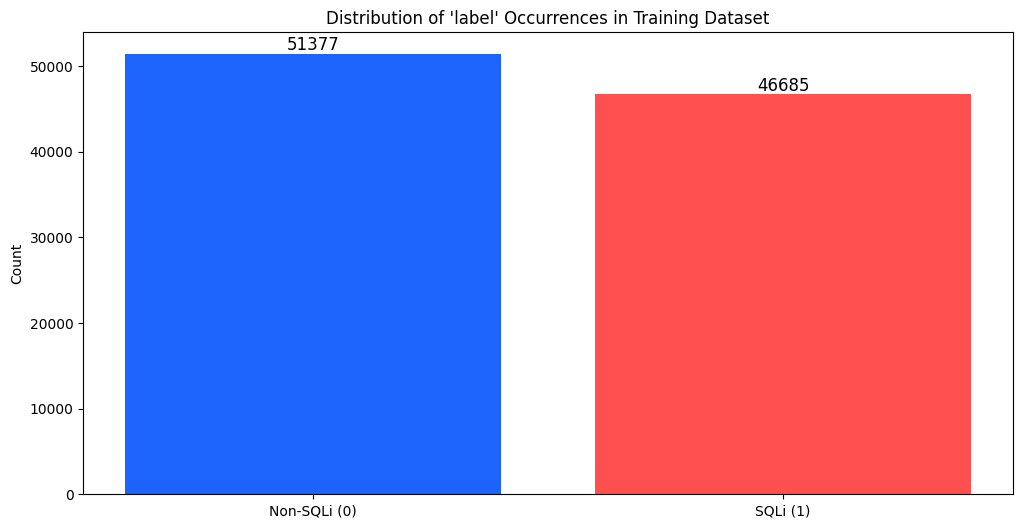

label
0    51377
1    46685
Name: count, dtype: int64


In [56]:
# visualization of class distribution (SQLi vs non-SQLi) in the training dataset
plt.figure(figsize=(12, 6))

train_counts = train_df['label'].value_counts()
plt.bar(['Non-SQLi (0)', 'SQLi (1)'], train_counts.values, color=["#1D64FD", "#ff4f4f"])
plt.title('Distribution of \'label\' Occurrences in Training Dataset')
plt.ylabel('Count')
plt.text(0, train_counts[0], str(train_counts[0]), ha='center', va='bottom', fontsize=12)
plt.text(1, train_counts[1], str(train_counts[1]), ha='center', va='bottom', fontsize=12)

plt.savefig('../results/traininglabel_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

label_counts = train_df['label'].value_counts()
print(label_counts)

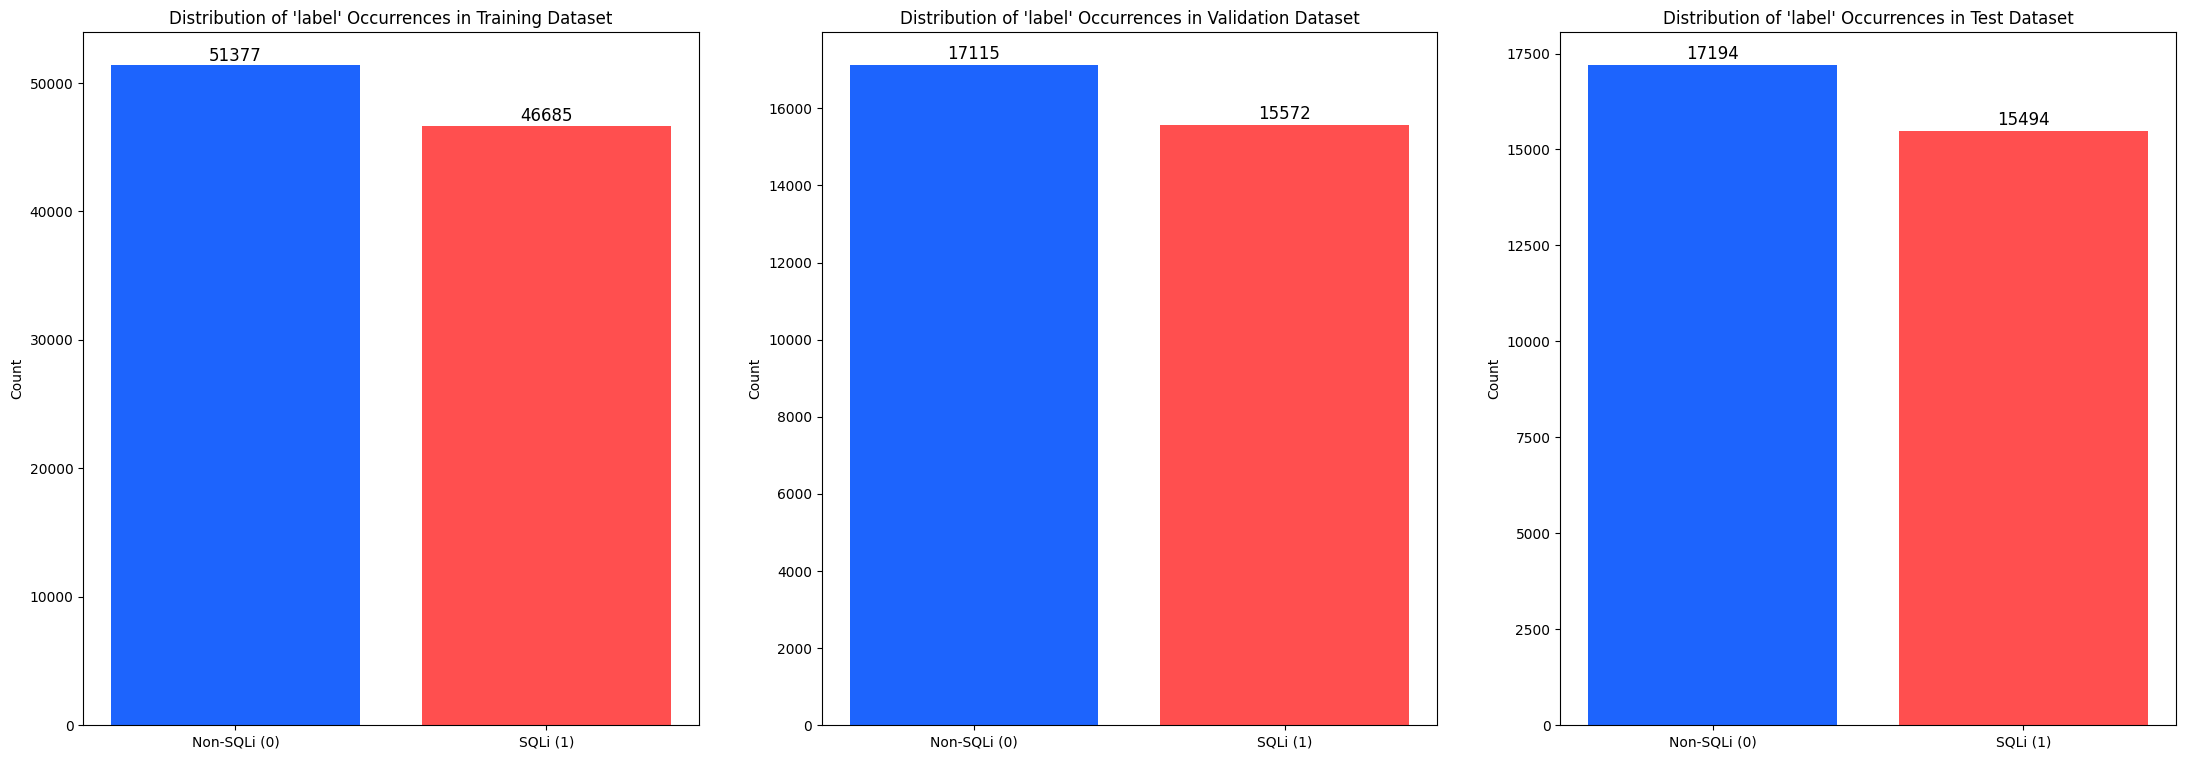

In [57]:
# visualization of class distribution (SQLi vs non-SQLi) in the training/validation/test dataset
fig, ax = plt.subplots(1, 3, figsize=(27, 9)) #rows, columns, figure size

train_counts = train_df['label'].value_counts()
val_counts = val_df['label'].value_counts()
test_counts = test_df['label'].value_counts()

ax[0].bar(['Non-SQLi (0)', 'SQLi (1)'], train_counts.values, color=["#1D64FD", "#ff4f4f"])
ax[0].set_title('Distribution of \'label\' Occurrences in Training Dataset')
ax[0].set_ylabel('Count')
ax[0].text(0, train_counts[0] + 50, str(train_counts[0]), ha='center', va='bottom', fontsize=12)
ax[0].text(1, train_counts[1] + 50, str(train_counts[1]), ha='center', va='bottom', fontsize=12)

ax[1].bar(['Non-SQLi (0)', 'SQLi (1)'], val_counts.values, color=["#1D64FD", "#ff4f4f"])
ax[1].set_title('Distribution of \'label\' Occurrences in Validation Dataset')
ax[1].set_ylabel('Count')
ax[1].text(0, val_counts[0] + 50, str(val_counts[0]), ha='center', va='bottom', fontsize=12)
ax[1].text(1, val_counts[1] + 50, str(val_counts[1]), ha='center', va='bottom', fontsize=12)

ax[2].bar(['Non-SQLi (0)', 'SQLi (1)'], test_counts.values, color=["#1D64FD", "#ff4f4f"])
ax[2].set_title('Distribution of \'label\' Occurrences in Test Dataset')
ax[2].set_ylabel('Count')
ax[2].text(0, test_counts[0] + 50, str(test_counts[0]), ha='center', va='bottom', fontsize=12)
ax[2].text(1, test_counts[1] + 50, str(test_counts[1]), ha='center', va='bottom', fontsize=12)

plt.savefig('../results/label_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [58]:
#conversion of datasets to Hugging Face format for easier use with Trainer API
train_dataset = Dataset.from_pandas(train_df[['query', 'label']])
val_dataset = Dataset.from_pandas(val_df[['query', 'label']])
test_dataset = Dataset.from_pandas(test_df[['query', 'label']])

print(train_dataset)
print(val_dataset)
print(test_dataset)

Dataset({
    features: ['query', 'label', '__index_level_0__'],
    num_rows: 98062
})
Dataset({
    features: ['query', 'label', '__index_level_0__'],
    num_rows: 32687
})
Dataset({
    features: ['query', 'label', '__index_level_0__'],
    num_rows: 32688
})


In [59]:
#Example of tokenization using BERT tokenizer - main priniciples that we will use later on
tokenizer = BertTokenizer.from_pretrained("bert-base-cased")
text = "admin' OR '1'='1"

# Tokenize and encode the text
encoding = tokenizer.encode(text)
print("Token IDs:", encoding)

# Convert token IDs back to tokens
tokens = tokenizer.convert_ids_to_tokens(encoding)
print("Tokens:", tokens)

Token IDs: [101, 8050, 7937, 112, 23066, 112, 122, 112, 134, 112, 122, 102]
Tokens: ['[CLS]', 'ad', '##min', "'", 'OR', "'", '1', "'", '=', "'", '1', '[SEP]']


What does BERT do?
BERT (Bi-directional Encoder Representation from Transforers - (Transformer***)) - open-source machine learning framework designed for natural language processing (NLP). So basically it can generate human like language and understand it.

So the Transformer***, in original architecture has bith encoders and decoders. The decision is to use encoder-only in BERT so the primary usage would be to understand input sentences like e.g. SQLi rather than generating output sentences.

Traditional lang. model process text inputs sequrntially (either going left->right or right->left), but this is a problem beacuse it limits the model's awareness to the immediate context preceding the target word. BERT uses a bi-directional approach, hence the name, where he considerts both the left and right context of words in sentence i.e. BERT looks at all the words simultaneously.

How to PRE-train BERT?
BERT undergoes Pre-training on LARGE amounts of data like our database, from unlabeled text to learn contextual embeddings.Our BERT will understnd context to recognize malicious intent beyond simple keyword matching.It will learn from captured syntax patterns to learn the difference, and classify whether it contains malicious patterns.

We do NOT re-train BERT from scratch, because this would require billions of tokens of text data and massive computational resources and time. We take the pre-trained BERT and fine-tune it on specific task, our SQLi injection.

So sequence of tokens are fed to the Transformer encoder. These tokens are first embedded into vectors and then processed in the neural network.The output is a sequence of vectors, each corresponding to an input token, providing contextualized representations.

SEQUENCE -> TOKENS -> FED TO TRANSFORMER ENCODER -> TOKENS CONVERTED INTO VECTORS -> VECTORS PROCESSED IN NEURAL NETWORK

```bash
Last Layer's   |||     |||      |||     |||     |||     |||     |||     |||     |||     
Hidden States   |  |||  |   |||  |  |||  |  |||  |  |||  |  |||  |  |||  |  |||  |
                |   |   |    |   |   |   |   |   |   |   |   |   |   |   |   |   |   
|-----------------------------------------------------------------------------------|
|                                                                                   |
|                            BERT = Transformer Encoder                             |
|                                                                                   | 
|-----------------------------------------------------------------------------------|
               |       |       |     |     |     |    |    |    |    |    |     |
Token IDs: [  101,   8050,   7937,  112, 23066, 112, 122, 112, 134, 112, 122,  102  ]
Tokens:    ['[CLS]', 'ad', '##min', "'", 'OR', "'", '1', "'", '=', "'", '1', '[SEP]']
```

BERT Architecture
The architecture is a multilazer bidirectional transformer encoder which is quite similar to the transformer model, it has 2 main architectures. BERT(BASE) has 12 layers in the Encoder stack while BERT(LARGE) has 24 layers in the Encoder stack. BERT architectures(BASE and LARGE) also have larger feedforward network between 768 and 1024 hidden units, attention heads between 12 and 16.BERT(BASE) contains 110M parameters while BERT(LARGE) has 340M parameters.

The model takes the CLS toekn as input first, then it is followed by a sequence of words as input.CLS stands for classification token.It then passes the input to the above layers. Each layer applies self-attention and passes the result through a feedforward network and then gets hand over to the next encoder.The model then outputs a vector of hidden size(around 768 for BERT(BASE)).Now this trained VECTOR can be used to perform a number of tasks such as classification, translation, etc.

In [60]:
# Token and Encode Function
def tokenize_and_encode(tokenizer, comments, labels, truncation=True, max_length=256):
    # Tokenize and encode the comment using the BERT tokenizer
    encoded = tokenizer.batch_encode_plus(
            #list of all querries
            comments,
            # Add special tokens like [CLS] and [SEP]
            add_special_tokens=True,
            # Truncate or pad the comment to 'max_length'
            max_length=max_length,
            # Pad the comment to 'max_length' with zeros if needed
            padding='max_length',
            truncation=True,
            # Return attention mask to mask padded tokens
            return_attention_mask=True,
            # Return PyTorch tensors
            return_tensors='pt'
        )

    # Append the tokenized input and attention mask to their respective lists
    input_ids = encoded['input_ids']
    attention_masks = encoded['attention_mask']
    # Convert the labels to a PyTorch tensor with the data type long(64)
    labels = torch.tensor(labels, dtype=torch.long)

    # Return the tokenized inputs, attention masks, and labels as PyTorch tensors
    return input_ids, attention_masks, labels

In [61]:
#Token initialization
tokenizer = BertTokenizer.from_pretrained('bert-base-cased', do_lower_case=True)

In [62]:
#Model initialization
model = BertForSequenceClassification.from_pretrained('bert-base-cased', num_labels=2)
#if GPU is available, move the model to GPU, else we will use MPS (Metal Performance Shaders) for Apple Silicon devices, and if neither is available, we will use CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
model = model.to(device)

print(f"Model loaded on device: {device}")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded on device: mps


In [63]:
#Tokenization and encoding of the datasets using the defined function above
train_input_ids, train_attention_masks, train_labels = tokenize_and_encode(
    tokenizer=tokenizer,
    comments=train_df['query'].tolist(),
    labels=train_df['label'].tolist(),
    truncation=True,
    max_length=512
)

val_input_ids, val_attention_masks, val_labels = tokenize_and_encode(
    tokenizer=tokenizer,
    comments=val_df['query'].tolist(),
    labels=val_df['label'].tolist(),
    truncation=True,
    max_length=512
)

test_input_ids, test_attention_masks, test_labels = tokenize_and_encode(
    tokenizer=tokenizer,
    comments=test_df['query'].tolist(),
    labels=test_df['label'].tolist(),
    truncation=True,
    max_length=512
)

print("Training comments:", train_df.shape)
print("Training input ids:", train_input_ids.shape)
print("Training attention masks:", train_attention_masks.shape)
print("Training labels:", train_labels.shape)

print("Validation comments:", val_df.shape)
print("Validation input ids:", val_input_ids.shape)
print("Validation attention masks:", val_attention_masks.shape)
print("Validation labels:", val_labels.shape)

print("Test comments:", test_df.shape)
print("Test input ids:", test_input_ids.shape)
print("Test attention masks:", test_attention_masks.shape)
print("Test labels:", test_labels.shape)


Training comments: (98062, 2)
Training input ids: torch.Size([98062, 512])
Training attention masks: torch.Size([98062, 512])
Training labels: torch.Size([98062])
Validation comments: (32687, 2)
Validation input ids: torch.Size([32687, 512])
Validation attention masks: torch.Size([32687, 512])
Validation labels: torch.Size([32687])
Test comments: (32688, 2)
Test input ids: torch.Size([32688, 512])
Test attention masks: torch.Size([32688, 512])
Test labels: torch.Size([32688])


We have 98062 SQL querrys in training set and 32687 SQL querrys in validation set. Each querry is converted in 256 or 512 tokens in our case. Short querrys are PAD-ed until 256 and longer are truncated on 256, also with 512 PAD-ed until 512 and longer are truncated on 512. With attention mask we can say to BERT which tokens should he read(so with 1 BERT pays attention, and with 0 he ignores it). 

Beacuse most querrys are shorter its better to use 256, hovever some querys are longer and therefore it may influnce the precission of the model.If we went with 512 to combine with the big ones it would be 2x slower and i would take 2x more resources.We trained both versions to compare the impact.

In [ ]:
#Testing if our tokenization and encoding works correctly - input ids, decoded ids, attention mask, and label

#train_df = train_df.reset_index(drop=True) #fixing gap hole in index after sampling
#print('Training Comments -->',train_df.loc[3]) #or iloc so we dont use again reset_index
#print('\nInput Ids -->\n',train_input_ids[3])
#print('\nDecoded Ids -->\n',tokenizer.decode(train_input_ids[3]))
#print('\nAttention Mask -->\n',train_attention_masks[3])
#print('\nLabels -->',train_labels[3])

Training Comments --> query    jk dv1z0r39am1wjiiumia9xrxdowuo87f 110dcc d0ej...
label                                                    1
Name: 3, dtype: object

Input Ids -->
 tensor([  101,   179,  1377,   173,  1964,  1475,  1584,  1568,  1197, 24786,
         2312,  1475,  2246,  3454,  3656,  1465,  1580,  1775,  1197,  1775,
         2572, 20236,  1186,  1604,  1559,  2087,  6745,  1181, 19515,   173,
         1568, 21024,  1179, 26303,  1477,  1643,  1403,  1775,   176,  1181,
        27347, 10493,  1775,  1477,  1830,  1643,  1181,  6112,  1495,  2087,
         5084,  1571,  1179,  1477,  1182,  1183,  3361,  1604,  3361,  1604,
        28101,  2312,  1204,  1495,  1306, 17653,   128,  1161,  1604,  1161,
         1477,  1377,  1775,  4426,  1545,  1181,  1559,  1477,  1306,   124,
          175,  1559,  1204,  1179,  1559,  1580,  1571,  1179,  1495,  1183,
         1495,  3293,  1495,  1197,  1580,  1181,  1775,  2246,  1324,  3361,
        17653, 15184,  1183,  2087,  4043

In [64]:
#Creating pytorch data loaders for training and validation datasets
batch_size = 32
train_dataset = TensorDataset(train_input_ids, train_attention_masks, train_labels)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(val_input_ids, val_attention_masks, val_labels)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

test_dataset = TensorDataset(test_input_ids, test_attention_masks, test_labels)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
#Testing if our data loaders work correctly - batch size, input ids, decoded ids, attention mask, and label

#with shuffle=True every time we have new batch of data, so we can see different examples in each epoch
#print('Batch Size :',train_loader.batch_size)
#Batch =next(iter(train_loader)) #returns a batch of data from the train_loader, which is an iterator that yields batches of data. The next() function retrieves the next batch from the iterator.
#print('Each Input ids shape :',Batch[0].shape)
#print('Input ids :\n',Batch[0][0]) 
#print('Corresponding Decoded text:\n',tokenizer.decode(Batch[0][0])) #we get first query from the batch and decode it to see the original text
#print('Corresponding Attention Mask :\n',Batch[1][0])
#print('Corresponding Label:',Batch[2][0])


Batch Size : 32
Each Input ids shape : torch.Size([32, 512])
Input ids :
 tensor([  101, 10801, 17204,  1200,  1110,   170, 11858,  2168,  3755,  7644,
         1114,  1199, 24132,  1121,  1900,  1231, 15863,  5871, 20754,  2133,
         8050, 15191,  1895,  1107,  1543,  1142,  2523,  1164,  1126,  6640,
         6767,  1200,  1150,  4090,  1471,  1678, 14551,  1114,   170,  3235,
         1910,  1118,   170,  6939,  1104,  4249, 13037,  1113,  1103,  3403,
         1111,  4228,  2740,  1554,  1104,  7251,  5948,  1107,  1103, 10987,
         5000,   119,   188,  7777,  5710,  2083, 15523,  4798,  1110,  7757,
         1112,   176, 22377,  2647,  1200,  1103,  6640,  6767,  1200,  2108,
         1107,  1103,  2168,   120,  2147, 10028,  1133,  1199,  1104,  1172,
         5397,  3070,  1113,  1103,  1413,  1104,  8362, 16330,  5562,   119,
         1111,  1103,  8590,  1104,  1103,  1273,  1463,   178,  4988,  1106,
        28117, 20080,  6696,  1139, 12962,   119,  1103,  1832,  110

## Model Training
---
**Skip this section if you already have a saved model.** Run cells **0–19** for data loading and tokenization, then jump to cell **29** to load the saved model.


In [176]:
#initializating the optimizer for training the model - standard procedure
#we are going to try to use the AdamW optimiyer, which refers to Adaptive Moment Estimation.Basically it combines
#the advantages of both the RMSprop(Root Mean Square Propagation) and AdaGrad(Adaptive Gradient Algorithm)

#for each model parameter, it includes moving avarages of the gradient and the squared gradient, which helps in adjusting the
#learning rate for various parameters during training

optimizer = AdamW(model.parameters(), lr=2e-5)

In [75]:
#Training model
import time

def time_format(seconds):
    minutes = int(seconds // 60)
    seconds = seconds % 60
    return f"{minutes}m {seconds:.2f}s"

def train_model(model,train_loader, optimizer, device, num_epochs):
    train_losses = []
    val_loses = []
    #We are looping thru given number of epochs
    for epoch in range(num_epochs):
        start_time = time.time() #measuring time for each epoch on 'mps' device

        #set the model to training
        model.train()

        #for each epoch we initaliye total_loss
        total_loss = 0

        #looping thru batches of data from the train_loader
        for batch in train_loader:
            #model and data need to be on same device aka in our case on CPU
            train_input_ids, train_attention_masks, train_labels = [t.to(device) for t in batch] #this line unpacks the batch that consists of 3 tensors, and packs then in own varaibles, and its sending them to the cpu
            optimizer.zero_grad() #we need to zero the gradients before each backward pass, otherwise they will accumulate

            outputs = model(input_ids=train_input_ids, attention_mask=train_attention_masks, labels=train_labels) #forward pass - we are passing the input ids, attention masks and labels to the model, and it will return the output which contains the loss and logits
            loss = outputs.loss #we are getting the loss from the output
            total_loss += loss.item() #we are adding the loss to the total loss for the
            loss.backward() #backward pass - we are calculating the gradients
            optimizer.step() #we are updating the model parameters based on the calculated gradients
        
        model.eval() #after each epoch we are setting the model to evaluation mode
        val_loss = 0
        
        with torch.no_grad(): #we are not calculating gradients during evaluation
            for batch in val_loader:
                train_input_ids, train_attention_masks, train_labels = [t.to(device) for t in batch] #setting to the same device

                outputs = model(input_ids=train_input_ids, attention_mask=train_attention_masks, labels=train_labels) #forward pass
                loss = outputs.loss #getting the loss
                val_loss += loss.item() #adding the loss to the total validation loss

        #printing average loss for the current epoch
        avg_train_loss = total_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        train_losses.append(avg_train_loss)
        val_loses.append(avg_val_loss)

        print(f"Epoch {epoch+1}, Training Loss: {avg_train_loss}, Validation Loss: {avg_val_loss}, Time: {time_format(time.time() - start_time)}")

    return train_losses, val_loses

#Moment of truth - we are going to train the model for 3 epochs and see how it performs

#train_model(model, train_loader, optimizer, device, num_epochs=1)
#train_losses, val_losses = train_model(model, train_loader, optimizer, device, num_epochs=1) #Epoch 1, Training Loss: 0.017636024737196745, Validation Loss: 0.0207665073122636
#train_losses, val_losses = train_model(model, train_loader, optimizer, device, num_epochs=3) 
                                                                                                #Epoch 1, Training Loss: 0.09553611398360153, Validation Loss: 0.01987610054598782, Time: 6m 11.08s
                                                                                                #Epoch 2, Training Loss: 0.01912913777476924, Validation Loss: 0.016973818425880107, Time: 6m 11.48s
                                                                                                #Epoch 3, Training Loss: 0.007968699619630766, Validation Loss: 0.017064841367225043, Time: 6m 11.24s
#full dataset training on 4 epohs
train_losses, val_losses = train_model(model, train_loader, optimizer, device, num_epochs=4)                                                                                               

Epoch 1, Training Loss: 0.01742245897733781, Validation Loss: 0.010222366263210221, Time: 113m 15.95s
Epoch 2, Training Loss: 0.006561756032551695, Validation Loss: 0.005659752761805312, Time: 112m 27.78s
Epoch 3, Training Loss: 0.004597151636423908, Validation Loss: 0.005100112577832571, Time: 112m 26.13s
Epoch 4, Training Loss: 0.003615668431380955, Validation Loss: 0.005682539138479915, Time: 112m 24.02s


1 Training model - 265 tokens:
Epoch 1, Training Loss: 0.017298108357549438, Validation Loss: 0.009088274127381396, Time: 50m 25.09s
Epoch 2, Training Loss: 0.008843207211001937, Validation Loss: 0.00913099885928224, Time: 50m 11.91s
Epoch 3, Training Loss: 0.005835668374152897, Validation Loss: 0.009297386203853116, Time: 50m 13.81s
Epoch 4, Training Loss: 0.005655362686402931, Validation Loss: 0.008406350389233312, Time: 50m 12.28s

Validation set of 0.0084 loss is exteremly low, we can say that the model almost perfectly classifies SQLi vs nonSQLi injections!

2 training model - 265 tokens:
Epoch 1, Training Loss: 0.018817852640185612, Validation Loss: 0.007949137360638067, Time: 49m 56.37s
Epoch 2, Training Loss: 0.008154052947616534, Validation Loss: 0.007961029537009185, Time: 49m 50.16s
Epoch 3, Training Loss: 0.006409635369487025, Validation Loss: 0.007848579694573683, Time: 49m 47.65s
Epoch 4, Training Loss: 0.005016843323079929, Validation Loss: 0.008179912978914872, Time: 49m 50.56s

3 training model - 512 tokens:
Epoch 1, Training Loss: 0.01742245897733781, Validation Loss: 0.010222366263210221, Time: 113m 15.95s
Epoch 2, Training Loss: 0.006561756032551695, Validation Loss: 0.005659752761805312, Time: 112m 27.78s
Epoch 3, Training Loss: 0.004597151636423908, Validation Loss: 0.005100112577832571, Time: 112m 26.13s
Epoch 4, Training Loss: 0.003615668431380955, Validation Loss: 0.005682539138479915, Time: 112m 24.02s

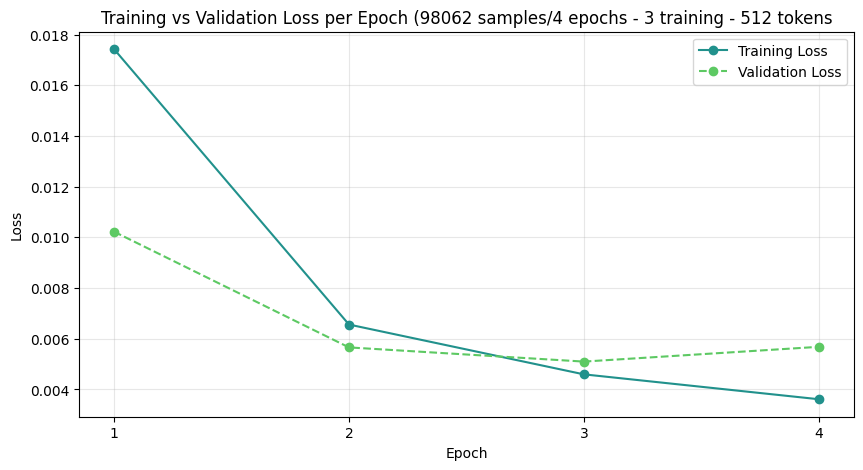

In [ ]:
#ONLY RUN AFTER TRAINING MODEL - CELL 22
# Visualization of training vs validation loss - checking for overfitting
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_losses, 'o-', color='#21918c', label='Training Loss')
plt.plot(epochs, val_losses, 'o--', color='#5dc963', label='Validation Loss')
plt.title('Training vs Validation Loss per Epoch (98062 samples/4 epochs - 3 training - 512 tokens')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.xticks(epochs)
plt.grid(True, alpha=0.3)
plt.savefig('../results/loss_curve_4epochs.png', dpi=300, bbox_inches='tight')
plt.show()

In [85]:
model.save_pretrained('../models/bert_sqli_model_4_epochs_512_tokens')
tokenizer.save_pretrained('../models/bert_sqli_tokenizer_4_epochs_512_tokens')
print("Model and tokenizer saved successfully!")

Model and tokenizer saved successfully!


---
## Loading existing model from **/models** folder
From here you can load a saved model and run evaluation and visualizations without retraining.

In [86]:
#loading PREVOUS TRAINED model and tokenizer
import torch
from transformers import BertTokenizer, BertForSequenceClassification

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

tokenizer = BertTokenizer.from_pretrained('../models/bert_sqli_tokenizer_4_epochs_512_tokens')
model = BertForSequenceClassification.from_pretrained('../models/bert_sqli_model_4_epochs_512_tokens').to(device)
model.eval()
print(f"Model loaded on device: {device}")


Model loaded on device: mps


In [87]:
#Evaluating the model on the testing set after training
def evaluate_model(model, test_loader, device):
    model.eval() #setting the model to evaluation mode
    
    true_labels = []
    predicted_probs = []

    with torch.no_grad(): #we are not calculating gradients during evaluation
        for batch in test_loader:
            test_input_ids, test_attention_masks, test_labels = [t.to(device) for t in batch] #setting to the same device

            #getting the models predictions for the validation set
            outputs = model(input_ids=test_input_ids, attention_mask=test_attention_masks) #forward pass - we are passing the input ids and attention masks to the model, and it will return the output which contains the logits
            
            #we are using argmax for multilabel classification - 
            #predicted_probs_batch = torch.argmax(outputs.logits, dim=1)
            predicted_probs_batch = torch.softmax(outputs.logits, dim=1)
            predicted_probs.append(predicted_probs_batch.cpu().numpy()) #we are moving the predicted probabilities to cpu and converting them to numpy array, and appending them to the list of predicted probabilities
            
            true_labels_batch = test_labels.cpu().numpy() #we are moving the true labels to cpu and converting them to numpy array
            true_labels.append(true_labels_batch) #we are appending the true labels to the list
    
    #now we are combining preedictions and labels for evaluation
    true_labels = np.concatenate(true_labels, axis=0) #we are concatenating the list of true labels into a single numpy array
    predicted_probs = np.concatenate(predicted_probs, axis=0) #we are concatenating

    #predicted_labels = (predicted_probs > 0.5).astype(int) #argmax
    #softmax - 0.3 thershold - take all rows only one column
    predicted_labels = (predicted_probs[:,1] > 0.2).astype(int) #we are converting the predicted probabilities to binary labels using a threshold of 0.2
    #predicted_labels = (predicted_probs[:,1] > 0.3).astype(int) #we are converting the predicted probabilities to binary labels using a threshold of 0.3
    #predicted_labels = (predicted_probs[:,1] > 0.5).astype(int) #we are converting the predicted probabilities to binary labels using a threshold of 0.5

    #calculating evaluations metrics
    accuracy = accuracy_score(true_labels, predicted_labels)
    precision = precision_score(true_labels, predicted_labels, average='binary')
    recall = recall_score(true_labels, predicted_labels, average='binary')
    f1 = f1_score(true_labels, predicted_labels, average='binary')

    #priniting the evaluation results
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    return true_labels, predicted_labels


#the function call for evaluating model -(98062 samples/4 epochs)
true_labels, predicted_labels = evaluate_model(model, test_loader, device)

Accuracy: 0.9986
Precision: 0.9987
Recall: 0.9983
F1 Score: 0.9985


With argmax on 0.5 threshold:
With a test set of 32,688 samples, the model made errors on only ~65 samples. Precision of 99.83% means that when the model flags a query as SQLi, it is almost always correct. Recall of 99.75% means it catches nearly all real SQLi attacks. F1 score of 99.79% confirms a perfect balance between precision and recall.

With softmax 0n 0.3 threshold:
With a test set of 32,688 samples, the model made errors on only ~57 samples. Precision of 99.81% means that when the model flags a query as SQLi, it is almost always correct. Recall of 99.83% means it catches nearly all real SQLi attacks. F1 score of 99.82% confirms a perfect balance between precision and recall.

With softmax on 0.5 threshold - same as argmax 0.5 threshold:
With a test set of 32,688 samples, the model made errors on only ~65 samples. Precision of 99.83% means that when the model flags a query as SQLi, it is almost always correct. Recall of 99.75% means it catches nearly all real SQLi attacks. F1 score of 99.79% confirms a perfect balance between precision and recall.

With softmax on 0.2 threshold:
With a test set of 32,688 samples, the model made errors on only ~56 samples. Precision of 99.79% means that when the model flags a query as SQLi, it is almost always correct. Recall of 99.85% means it catches nearly all real SQLi attacks. F1 score of 99.82% confirms a perfect balance between precision and recall.

With softmax on 0.2 threshold - 512 tokens:
With a test set of 32,688 samples, the model made errors on only ~47 samples. Precision of 99.87% means that when the model flags a query as SQLi, it is almost always correct. Recall of 99.83% means it catches nearly all real SQLi attacks. F1 score of 99.85% confirms a perfect balance between precision and recall.

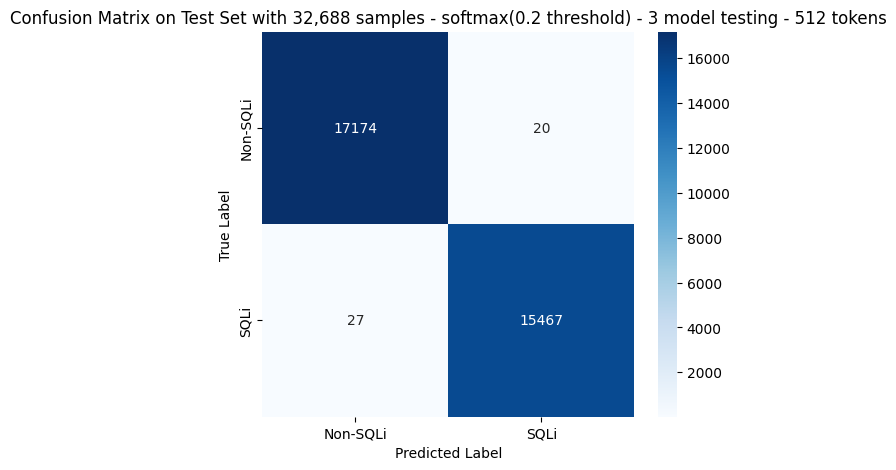

In [67]:
#Visualising the confusion matrix for the test set
cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-SQLi', 'SQLi'], yticklabels=['Non-SQLi', 'SQLi'])
plt.title('Confusion Matrix on Test Set with 32,688 samples - softmax(0.2 threshold) - 3 model testing - 512 tokens')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('../results/confusion_matrix_on_test_softmax_0_2_3_model_testing_512_tokens.png', dpi=300, bbox_inches='tight')
plt.show()

On argmax with 0.5 threshold: 
(TN) - 17168 - legitimate queries that were correctly classified as non-SQLi
(FP) - 26 - legitimate queries that were incorrectly classified as SQLi
(FN) - 38 - missed SQLi 
(TP) - 15456 - SQLi queries that were correctly classified as SQLi

So we can say in every ~400 attacs only 1 injection is passing
38/15456 = 0.00245859
1/0.00245 = 408 -> so if 0.245% attacs are passing, only 1 in 408 attacs

On softmax with 0.3 threshold:
(TN) - 17168 - legitimate queries that were correctly classified as non-SQLi
(FP) - 30 - legitimate queries that were incorrectly classified as SQLi
(FN) - 27 - missed SQLi 
(TP) - 15456 - SQLi queries that were correctly classified as SQLi

So we can say in every ~400 attacs only 1 injection is passing
27/15456 = 0.00174565
1/0.00174 = 572 -> so if 0.174% attacs are passing, only 1 in 572 attacs

On softmax with 0.5 threshold:
(TN) - 17168 - legitimate queries that were correctly classified as non-SQLi
(FP) - 26 - legitimate queries that were incorrectly classified as SQLi
(FN) - 38 - missed SQLi 
(TP) - 15456 - SQLi queries that were correctly classified as SQLi

So we can say in every ~400 attacs only 1 injection is passing
38/15456 = 0.00245859
1/0.00245 = 408 -> so if 0.245% attacs are passing, only 1 in 408 attacs

On softmax with 0.2 threshold:
(TN) - 17168 - legitimate queries that were correctly classified as non-SQLi
(FP) - 32 - legitimate queries that were incorrectly classified as SQLi
(FN) - 24 - missed SQLi 
(TP) - 15456 - SQLi queries that were correctly classified as SQLi

So we can say in every ~400 attacs only 1 injection is passing
24/15456 = 0.0015528
1/0.00155 = 408 -> so if 0.155% attacs are passing, only 1 in 645 attacs

On softmax with 0.2 threshold - 512 tokens:
(TN) - 17168 - legitimate queries that were correctly classified as non-SQLi
(FP) - 20 - legitimate queries that were incorrectly classified as SQLi
(FN) - 27 - missed SQLi 
(TP) - 15456 - SQLi queries that were correctly classified as SQLi

So we can say in every ~400 attacs only 1 injection is passing
27/15456 = 0.00174565
1/0.00174 = 572 -> so if 0.174% attacs are passing, only 1 in 572 attacs

On softmax with 0.3 threshold - 512 tokens:
(TN) - 17168 - legitimate queries that were correctly classified as non-SQLi
(FP) - 15 - legitimate queries that were incorrectly classified as SQLi
(FN) - 33 - missed SQLi 
(TP) - 15456 - SQLi queries that were correctly classified as SQLi

So we can say in every ~400 attacs only 1 injection is passing
27/15456 = 0.002135
1/0.002135 = 572 -> so if 0.2135% attacs are passing, only 1 in 468 attacs

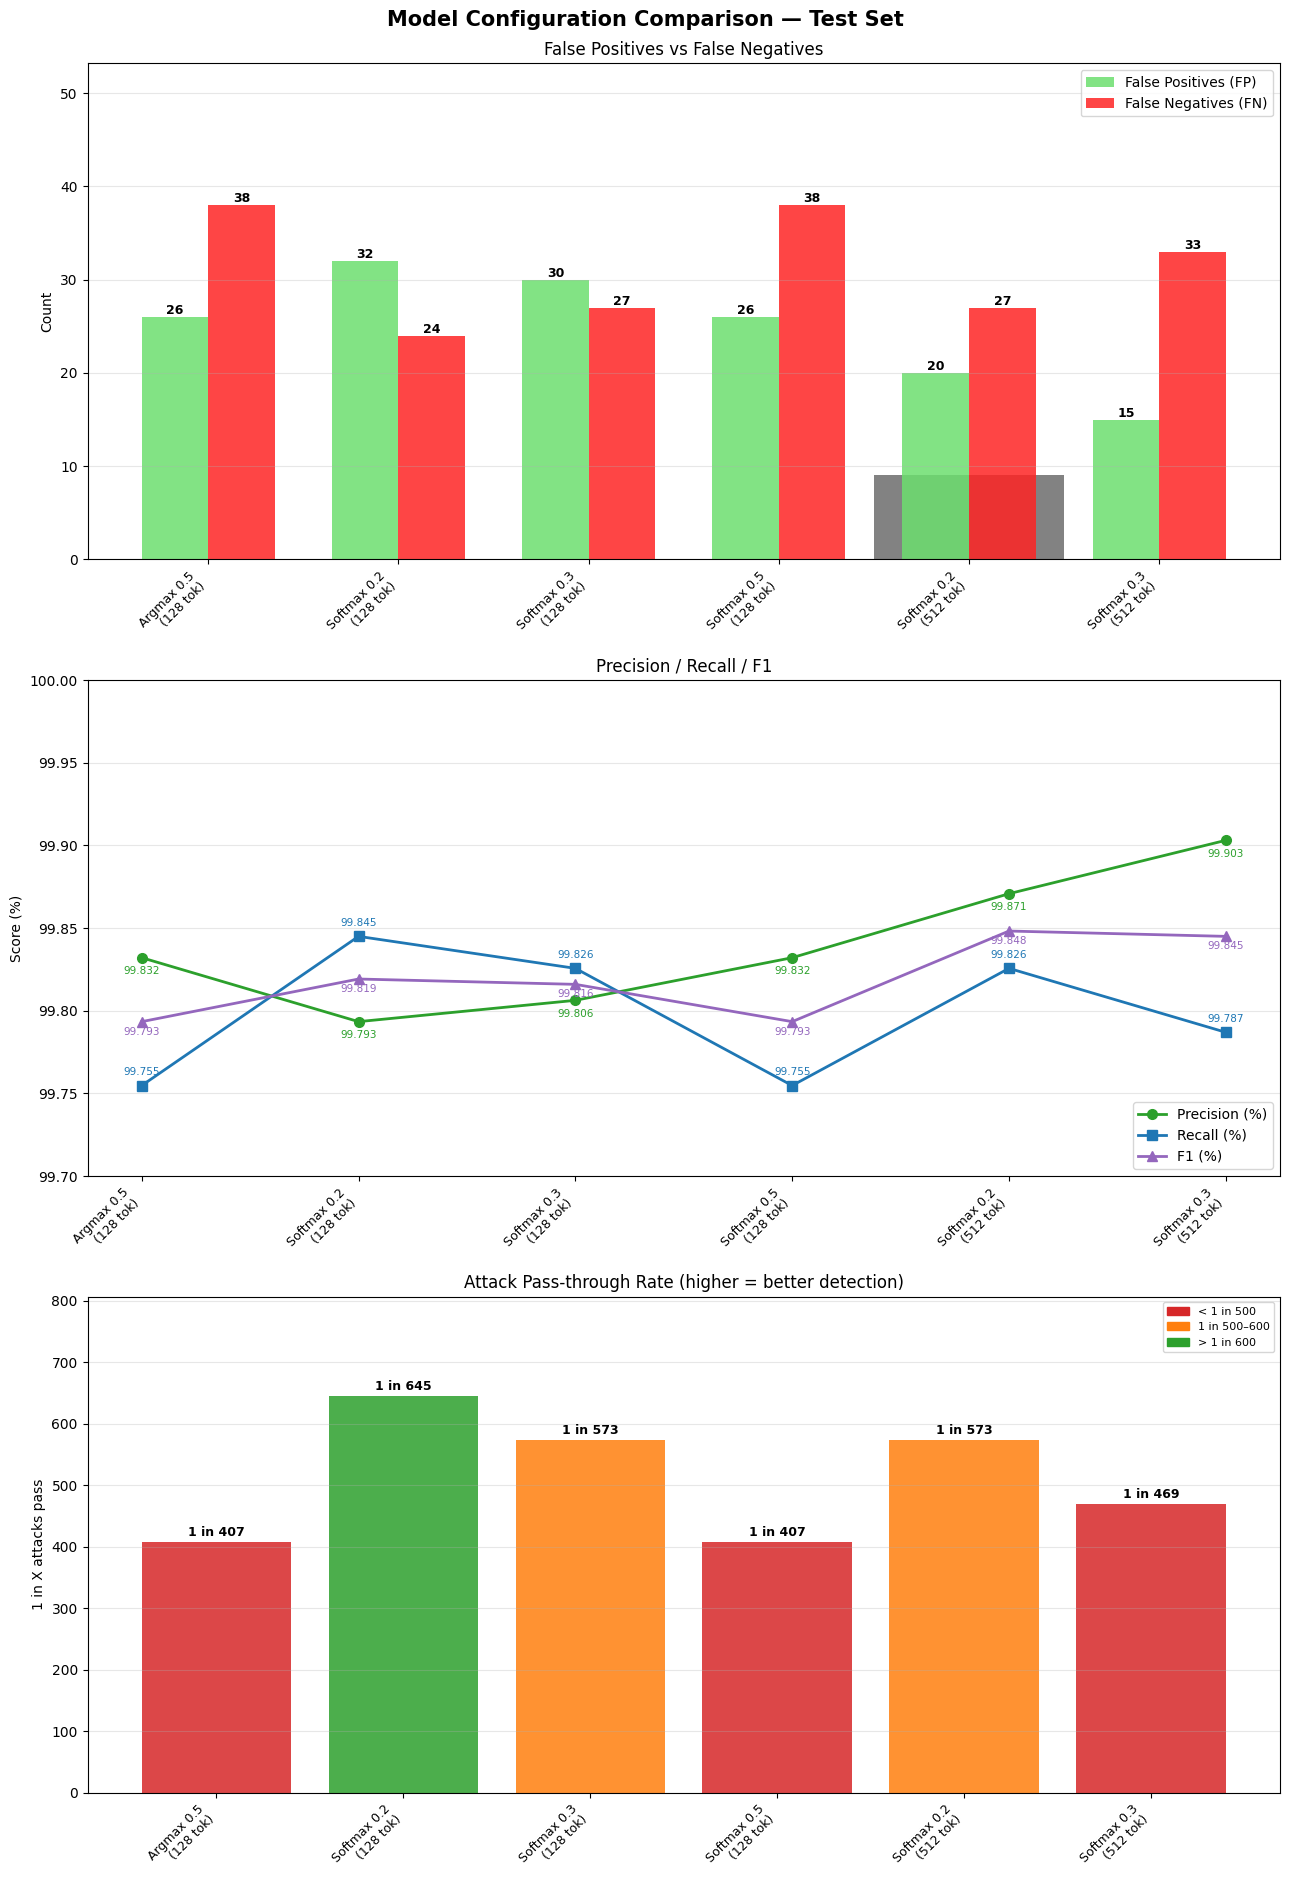

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches #for manually constructing legends
import numpy as np
from matplotlib.patches import Rectangle

# Data from our observations from above from confusion matrixs
configs = {
    "Argmax 0.5\n(128 tok)":      {"TN": 17168, "FP": 26, "FN": 38, "TP": 15456},
    "Softmax 0.2\n(128 tok)":     {"TN": 17168, "FP": 32, "FN": 24, "TP": 15456},
    "Softmax 0.3\n(128 tok)":     {"TN": 17168, "FP": 30, "FN": 27, "TP": 15456},
    "Softmax 0.5\n(128 tok)":     {"TN": 17168, "FP": 26, "FN": 38, "TP": 15456},
    "Softmax 0.2\n(512 tok)":     {"TN": 17168, "FP": 20, "FN": 27, "TP": 15456},
    "Softmax 0.3\n(512 tok)":     {"TN": 17168, "FP": 15, "FN": 33, "TP": 15456},
}

labels = list(configs.keys())
fps, fns, accs, precs, recs, f1s, one_in_x = [], [], [], [], [], [], []

for c in configs.values():
    TN, FP, FN, TP = c["TN"], c["FP"], c["FN"], c["TP"]
    total = TN + FP + FN + TP
    acc  = (TP + TN) / total
    prec = TP / (TP + FP)
    rec  = TP / (TP + FN)
    f1   = 2 * prec * rec / (prec + rec)
    miss_rate = FN / (TP + FN)
    fps.append(FP)
    fns.append(FN)
    accs.append(acc * 100)
    precs.append(prec * 100)
    recs.append(rec * 100)
    f1s.append(f1 * 100)
    one_in_x.append(1 / miss_rate)

x = np.arange(len(labels))
fig, ax = plt.subplots(3, 1, figsize=(13, 19))
fig.suptitle("Model Configuration Comparison — Test Set", fontsize=15, fontweight='bold', y=0.99)

#Plot 1: FP(false positive) and FN(false negative)
w = 0.35  #width of columns
b1 = ax[0].bar(x - w/2, fps, w, label='False Positives (FP)', color="#6cde6e", alpha=0.85)
b2 = ax[0].bar(x + w/2, fns, w, label='False Negatives (FN)', color="#fe2424", alpha=0.85)

for bar in list(b1) + list(b2):
    ax[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(), str(int(bar.get_height())), ha='center', va='bottom', fontsize=9, fontweight='bold')
    # Grey - (x, y_start), width, height in bottom left corner, width(x1-x2), height(y1-y2), zorder - goes below points
    rect = Rectangle((3.5, 0), 1, 30, facecolor='grey', alpha=0.25, zorder=0, lw=1.5)
    ax[0].add_patch(rect)

ax[0].set_xticks(x)
ax[0].set_xticklabels(labels, rotation=45, ha='right',fontsize=9)
ax[0].set_ylabel("Count")
ax[0].set_title("False Positives vs False Negatives")
ax[0].legend(); 
ax[0].set_ylim(0, max(max(fps), max(fns)) * 1.4)
ax[0].grid(axis='y', alpha=0.3)

#Plot 2: Precision, Recall, F1
ax[1].plot(x, precs, 'o-', color='#2ca02c', label='Precision (%)', lw=2, ms=7)
ax[1].plot(x, recs,  's-', color='#1f77b4', label='Recall (%)',    lw=2, ms=7)
ax[1].plot(x, f1s,   '^-', color='#9467bd', label='F1 (%)',        lw=2, ms=7)
for i, (p, r, f) in enumerate(zip(precs, recs, f1s)):
    ax[1].text(i, p - 0.011, f'{p:.3f}', ha='center', va='bottom', fontsize=7.5, color='#2ca02c')
    ax[1].text(i, r + 0.011, f'{r:.3f}', ha='center', va='top',    fontsize=7.5, color='#1f77b4')
    ax[1].text(i, f - 0.003, f'{f:.3f}', ha='center', va='top',    fontsize=7.5, color='#9467bd')
ax[1].set_xticks(x); 
ax[1].set_xticklabels(labels, fontsize=9, rotation=45, ha='right',)
ax[1].set_ylabel("Score (%)")
ax[1].set_title("Precision / Recall / F1")
ax[1].legend(loc='lower right')
ax[1].set_ylim(99.7, 100.00)
ax[1].grid(axis='y', alpha=0.3)

#Plot 3: 1 in X attacks passing
colors = ['#d62728' if v < 500 else '#ff7f0e' if v < 600 else '#2ca02c' for v in one_in_x]
bars = ax[2].bar(x, one_in_x, color=colors, alpha=0.85, lw=0.5)
for bar, val in zip(bars, one_in_x):
    ax[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'1 in {int(val)}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax[2].set_xticks(x)
ax[2].set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax[2].set_ylabel("1 in X attacks pass")
ax[2].set_title("Attack Pass-through Rate (higher = better detection)")
ax[2].set_ylim(0, max(one_in_x) * 1.25)
ax[2].grid(axis='y', alpha=0.3)
legend_patches = [
    mpatches.Patch(color="#d62728", label='< 1 in 500'),
    mpatches.Patch(color='#ff7f0e', label='1 in 500–600'),
    mpatches.Patch(color='#2ca02c', label='> 1 in 600'),
]
ax[2].legend(handles=legend_patches, fontsize=8)

plt.tight_layout()
plt.savefig('../results/model_comparison_test_set.png', dpi=300, bbox_inches='tight')
plt.show()


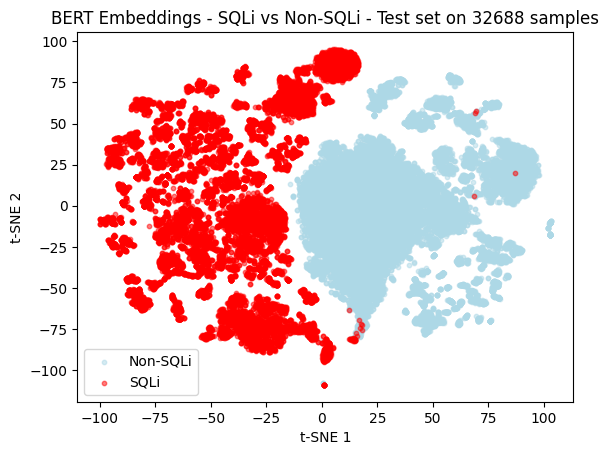

In [200]:
#t-SNE visualization of BERT embeddings for the test set
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE
import torch

#Generating BERT embeddings for the test set 
model.eval()
embeddings = []
labels_list = []

with torch.no_grad():
    for batch in test_loader:
        test_input_ids, test_attention_masks, test_labels = [t.to(device) for t in batch]
        outputs = model(input_ids=test_input_ids, attention_mask=test_attention_masks, output_hidden_states=True)
        # CLS token = representation of the whole query
        cls_embeddings = outputs.hidden_states[-1][:, 0, :].cpu().numpy()
        embeddings.append(cls_embeddings)
        labels_list.extend(test_labels.cpu().numpy())

X = np.concatenate(embeddings, axis=0)
y = np.array(labels_list)

# t-SNE preduces 768D -> 2D dimensionality
X_2d = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(X)

# Split on classes
idx_0 = np.where(y == 0)
idx_1 = np.where(y == 1)

# Scatter plot
plt.scatter(X_2d[idx_0, 0], X_2d[idx_0, 1], c='lightblue', label='Non-SQLi', alpha=0.5, s=10)
plt.scatter(X_2d[idx_1, 0], X_2d[idx_1, 1], c='red', label='SQLi', alpha=0.5, s=10)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend()
plt.title('BERT Embeddings - SQLi vs Non-SQLi - Test set on 32688 samples')
plt.savefig('../results/tsne_scatter_32688_samples_test.png', dpi=300, bbox_inches='tight')
plt.show()


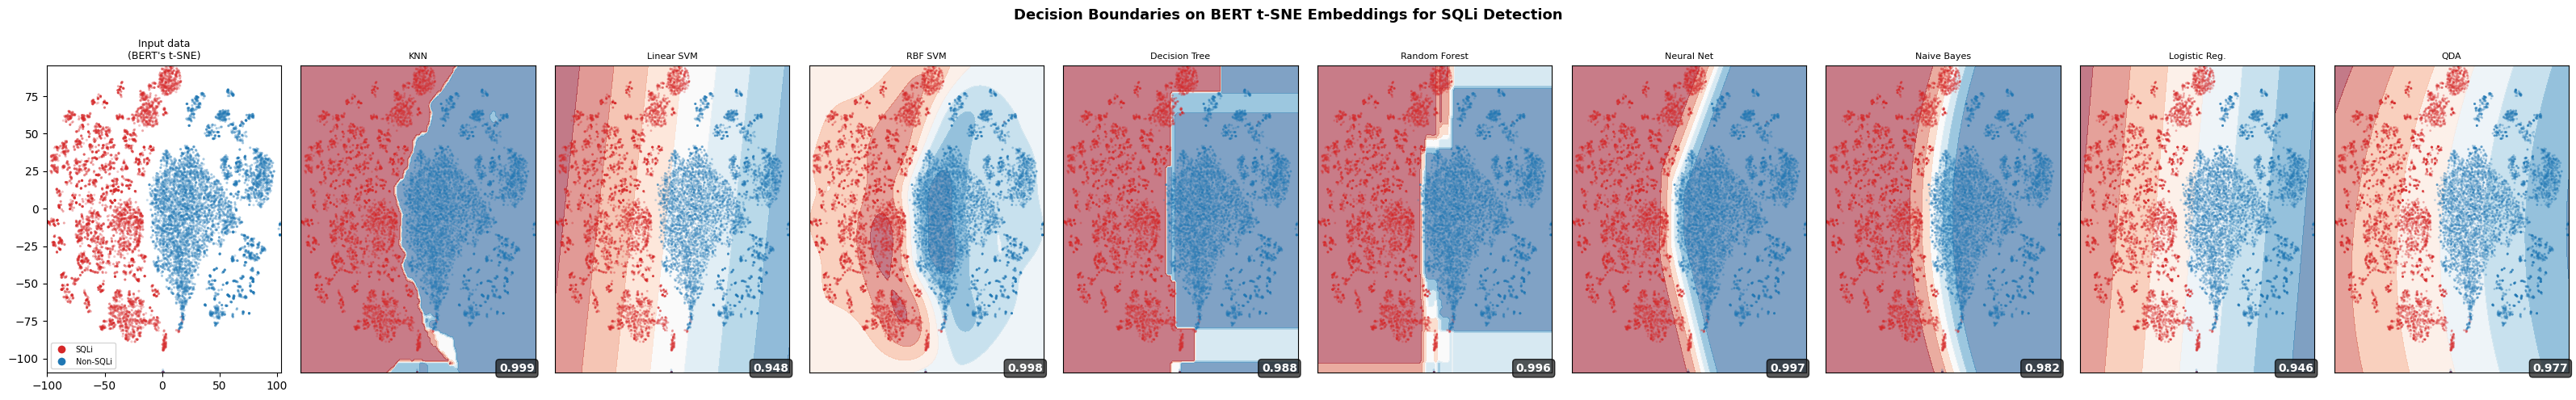

In [206]:
# Authors: The scikit-learn developers (modified by me to display BERT's + t-SNE coordinates)
# SPDX-License-Identifier: BSD-3-Clause
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Sample of 10000 points (just for basic visualization, we don't need everything)
np.random.seed(42)
idx = np.random.choice(len(X_2d), size=10000, replace=False)
X_vis = X_2d[idx]
y_vis = y[idx]

X_train, X_test, y_train, y_test = train_test_split( X_vis, y_vis, test_size=0.3, random_state=42)

names = ["KNN", "Linear SVM", "RBF SVM", "Decision Tree","Random Forest", "Neural Net", "Naive Bayes", "Logistic Reg.", "QDA"]

classifiers = [
    KNeighborsClassifier(5),
    SVC(kernel="linear", C=0.025, random_state=42),
    SVC(gamma=2, C=1, random_state=42),
    DecisionTreeClassifier(max_depth=5, random_state=42),
    RandomForestClassifier(max_depth=5, n_estimators=10, random_state=42),
    MLPClassifier(alpha=1, max_iter=500, random_state=42),
    GaussianNB(),
    LogisticRegression(random_state=42),
    QuadraticDiscriminantAnalysis(),
]

cm = plt.cm.RdBu_r #_r reverses color map 0 is blue, 1 is red
cm_bright = ListedColormap(["#1f77b4", "#d62728"])  #red=SQLi, blue=Non-SQLi

x_min, x_max = X_vis[:, 0].min() - 0.5, X_vis[:, 0].max() + 0.5
y_min, y_max = X_vis[:, 1].min() - 0.5, X_vis[:, 1].max() + 0.5

fig, ax = plt.subplots(1, len(classifiers) + 1, figsize=(32, 5))
fig.suptitle("Decision Boundaries on BERT t-SNE Embeddings for SQLi Detection", fontsize=13, fontweight='bold')

#Our input data - Test set from BERT's t-SNE
ax[0].scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, alpha=0.4, s=5, edgecolors='none')
ax[0].scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=cm_bright, alpha=0.25, s=5, edgecolors='none')
ax[0].set_xlim(x_min, x_max)
ax[0].set_ylim(y_min, y_max)
ax[0].set_title("Input data\n(BERT's t-SNE)", fontsize=9)
ax[0].legend(handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#d62728', markersize=8, label='SQLi'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#1f77b4', markersize=8, label='Non-SQLi')
], fontsize=7, loc='lower left')

# Classifier comparison
for i, (name, clf) in enumerate(zip(names, classifiers)):
    clf = make_pipeline(StandardScaler(), clf)
    clf.fit(X_train, y_train)
    score = clf.score(X_test, y_test)

    DecisionBoundaryDisplay.from_estimator(clf, X_vis, cmap=cm, alpha=0.55, ax=ax[i+1], eps=0.5)
    ax[i+1].scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, alpha=0.35, s=4, edgecolors='none')
    ax[i+1].scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=cm_bright, alpha=0.25, s=4, edgecolors='none')
    ax[i+1].set_xlim(x_min, x_max)
    ax[i+1].set_ylim(y_min, y_max)
    ax[i+1].set_xticks(())
    ax[i+1].set_yticks(())
    ax[i+1].set_title(name, fontsize=8)
    ax[i+1].text(x_max - 0.5, y_min + 0.8, f'{score:.3f}', size=10, ha='right', fontweight='bold', color='white', bbox=dict(boxstyle='round,pad=0.3', facecolor='#222', alpha=0.75))

plt.tight_layout()
plt.savefig('../results/classifier_comparison_tsne.png', dpi=200, bbox_inches='tight')
plt.show()

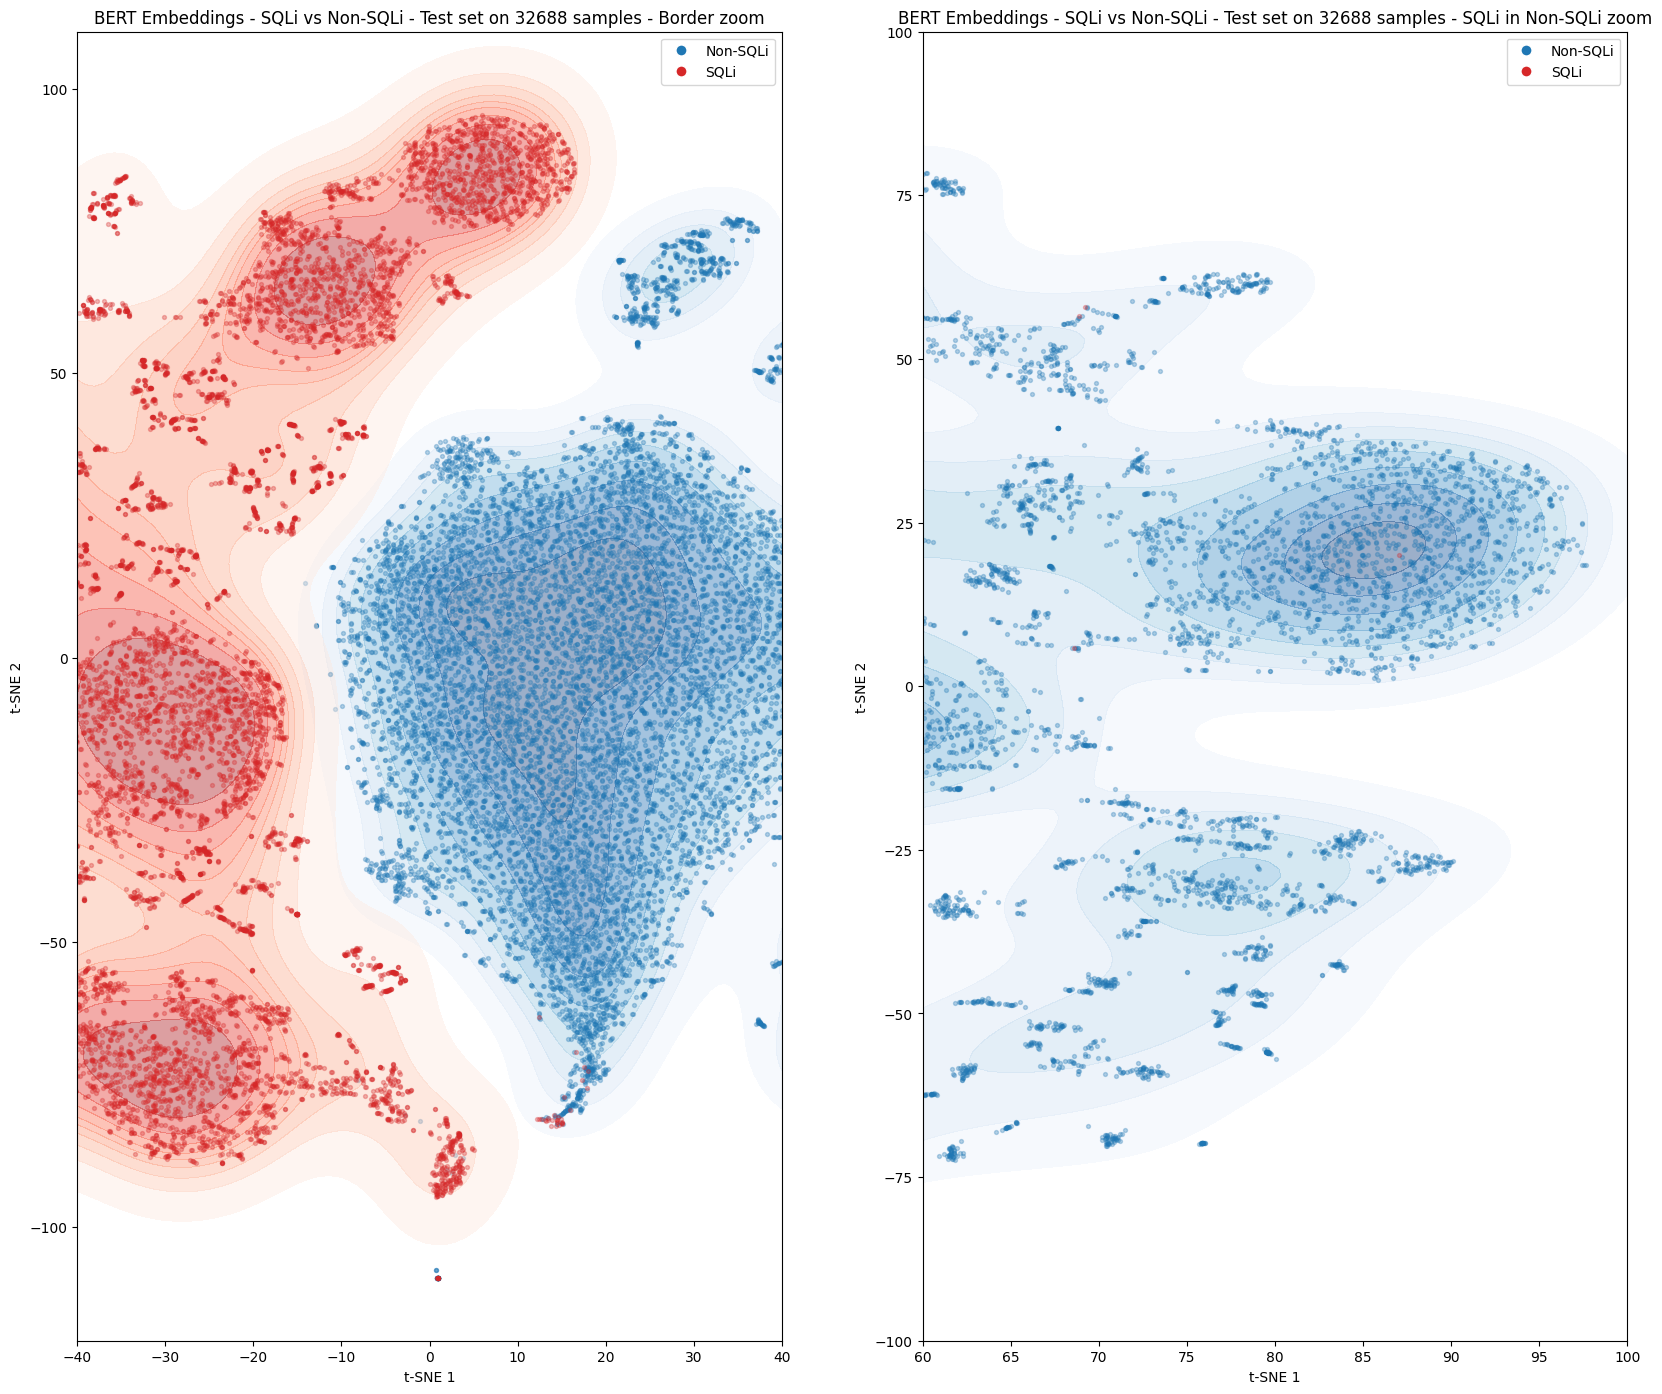

In [135]:
#KDE plot - Kernel Density Estimation - density plot
import seaborn as sns
from matplotlib.lines import Line2D

fig, ax = plt.subplots(1,2,figsize=(20, 17))

for label, cmap, color, name in [(0, 'Blues', '#1f77b4', 'Non-SQLi'), (1, 'Reds', '#d62728', 'SQLi')]:
    idx = np.where(y == label)
    points = X_2d[idx]
    sns.kdeplot(x=points[:, 0], y=points[:, 1], cmap=cmap, fill=True, alpha=0.4, ax=ax[0])
    sns.kdeplot(x=points[:, 0], y=points[:, 1], cmap=cmap, fill=True, alpha=0.4, ax=ax[1])
    ax[0].scatter(points[:, 0], points[:, 1], c=color, alpha=0.3, s=8)
    ax[1].scatter(points[:, 0], points[:, 1], c=color, alpha=0.3, s=8)

# zoom on border
ax[0].set_xlim(-40, 40)
ax[0].set_ylim(-120, 110)
ax[1].set_xlim(60, 100)
ax[1].set_ylim(-100, 100)

# custom legend
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor='#1f77b4', markersize=8, label='Non-SQLi'),
                   Line2D([0], [0], marker='o', color='w', markerfacecolor='#d62728', markersize=8, label='SQLi')]
ax[0].legend(handles=legend_elements)
ax[0].set_xlabel('t-SNE 1')
ax[0].set_ylabel('t-SNE 2')
ax[0].set_title('BERT Embeddings - SQLi vs Non-SQLi - Test set on 32688 samples - Border zoom')
ax[1].legend(handles=legend_elements)
ax[1].set_xlabel('t-SNE 1')
ax[1].set_ylabel('t-SNE 2')
ax[1].set_title('BERT Embeddings - SQLi vs Non-SQLi - Test set on 32688 samples - SQLi in Non-SQLi zoom')
plt.savefig('../results/tsne_kde_32688_samples_border_test_wider_collisions.png', dpi=300, bbox_inches='tight')
plt.show()

On 2000 samples - test before the entire study on Test set:
Red small cluster (above ~-10, 40) — SQLi queries that are structurally different from the main group, e.g. different attack type (blind SQLi, time-based, etc.)
Blue small cluster (right ~65, 0) — Non-SQLi queries that are structurally different, eg maybe numeric queries or short strings
t-SNE groups similar queries together — if they are separated, they are of a different shape/structure but still of the same class.

On 32688 samples - Test set:
Red (SQLi) clearly left, blue (Non-SQLi) clearly right
Almost no mixing between classes
Small red cluster at the top (~65-85, ~0-75) — different type of SQLi attack
Small mixing at the border (~15, ~-80) — those are the ~47 wrong predictions

This is actually an interesting finding — it shows that the dataset has multiple subtypes of SQLi attacks.

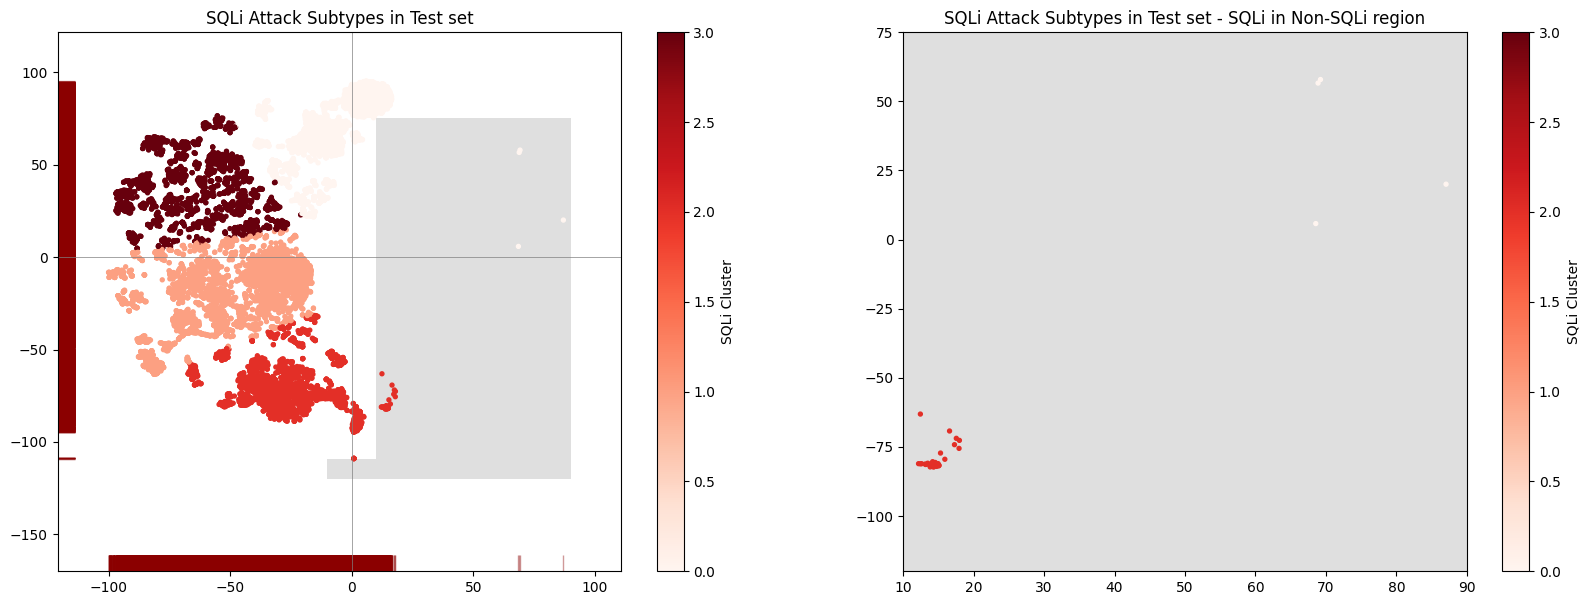

In [ ]:
#Subtypes of SQLi attacks in the test set
from sklearn.cluster import KMeans
from matplotlib.patches import Rectangle

# take only SQLi points
sqli_idx = np.where(y == 1)
sqli_points = X_2d[sqli_idx]

kmeans = KMeans(n_clusters=4, random_state=42)
cluster_labels = kmeans.fit_predict(sqli_points)

fig, ax = plt.subplots(1,2, figsize=(20, 7))
ax_0 = ax[0].scatter(sqli_points[:, 0], sqli_points[:, 1], c=cluster_labels, cmap='Reds', alpha=1, s=8)
ax_1 = ax[1].scatter(sqli_points[:, 0], sqli_points[:, 1], c=cluster_labels, cmap='Reds', alpha=1, s=8)

ax[1].set_xlim(10,90)
ax[1].set_ylim(-120,75)

# Grey - (x, y_start), width, height in bottom left corner, width(x1-x2), height(y1-y2), zorder - goes below points
rect = Rectangle((10, -120), 80, 195, facecolor='grey', alpha=0.25, zorder=0, lw=1.5)
rect2 = Rectangle((-10, -120), 20, 11, facecolor='grey', alpha=0.25, zorder=0, lw=1.5)
rect3 = Rectangle((10, -120), 80, 195, facecolor='grey', alpha=0.25, zorder=0, lw=1.5)
ax[0].add_patch(rect)
ax[0].add_patch(rect2)
ax[1].add_patch(rect3)
import seaborn as sns

sns.rugplot(x=sqli_points[:, 0], y=sqli_points[:, 1], ax=ax[0], alpha=0.4, height=0.03, color='darkred')

ax[0].axvline(x=0, color='grey', linestyle='-', lw=0.5)
ax[0].axhline(y=0, color='grey', linestyle='-', lw=0.5)

plt.colorbar(ax_0, label='SQLi Cluster')
plt.colorbar(ax_1, label='SQLi Cluster')
ax[0].set_title('SQLi Attack Subtypes in Test set')
ax[1].set_title('SQLi Attack Subtypes in Test set - SQLi in Non-SQLi region')
plt.savefig('../results/sqli_clusters_test.png', dpi=300)
plt.show()

#for cluster_id in range(4):
#    print(f"\n--- Cluster {cluster_id} ---")
#    cluster_mask = cluster_labels == cluster_id
#    # dohvati originalne upite tog klastera
#    sqli_queries = test_df[test_df['label'] == 1]['query'].values
#    print(sqli_queries[cluster_mask][:3])

Cluster 0 — Obfuscated/Fuzzing attacks
Random characters (>m_h]z9]rb, @ud]h;>njn) + SQL payload at the end
Attacker tries to bypass WAF with random noise
Contains UNION SELECT, dbms_pipe.receive_message

Cluster 1 — Buffer overflow / Oracle attacks
Long strings (xxx..., rrr...) + SQL at the end
ctxsys.drithsx.sn, chr() functions → Oracle database specific
It tries to overflow the buffer and insert the payload

Cluster 2 — Injection into normal text (most dangerous)
It looks like a normal movie review but contains SQLi at the end
dbms_utility.sqlid_to_sqlhash, boolean-based blind SQLi
The most difficult to detect with classical methods

Cluster 3 — UNION/Boolean blind SQLi
Clean SQLi without noise
UNION ALL SELECT, rlike, boolean mode
classic attacks, easiest to detect

---
## Unloading model before exiting

In [81]:
#Unloading model and freeing up GPU memory
model.cpu()
del model
del tokenizer
import gc
gc.collect()
torch.mps.empty_cache()
print("Model unloaded!")

Model unloaded!
